In [17]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression

In [18]:
class DoSDetector(nn.Module):
    def __init__(self, input_dim=29, num_classes=2):
        super(DoSDetector, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        return self.output(x)

In [19]:
def load_and_preprocess(filepath):
    df = pd.read_csv(filepath)
    
    # 1. Parity Drop (Ensure these match all other models)
    cols_to_drop = [
        "Fwd Packets Length Total", "Bwd Packets Length Total", "Fwd Packet Length Max", 
        "Bwd Packet Length Max", "Fwd Packet Length Min", "Bwd Packet Length Min",
        "Fwd Packet Length Std", "Bwd Packet Length Std", "Flow IAT Std", "Flow IAT Total",
        "Fwd IAT Std", "Fwd IAT Max", "Fwd IAT Min", "Bwd IAT Total", "Bwd IAT Std", 
        "Bwd IAT Max", "Bwd IAT Min", "Fwd PSH Flags", "Bwd PSH Flags", "Fwd URG Flags", 
        "Bwd URG Flags", "Packet Length Variance", "PSH Flag Count", "URG Flag Count", 
        "CWE Flag Count", "ECE Flag Count", "Down/Up Ratio", "Avg Packet Size",
        "Avg Fwd Segment Size", "Avg Bwd Segment Size", "Fwd Avg Bytes/Bulk", 
        "Fwd Avg Packets/Bulk", "Fwd Avg Bulk Rate", "Bwd Avg Bytes/Bulk", 
        "Bwd Avg Packets/Bulk", "Bwd Avg Bulk Rate", "Subflow Bwd Bytes",
        "Init Fwd Win Bytes", "Init Bwd Win Bytes", "Fwd Act Data Packets", 
        "Fwd Seg Size Min", "Active Mean", "Active Std", "Active Max", "Active Min",
        "Idle Mean", "Idle Std", "Idle Max", "Idle Min"
    ]
    df = df.drop(columns=cols_to_drop, axis=1, errors='ignore')
    
    # 2. Fix infinity and clip before log
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)
    X = df.drop('Label', axis=1).clip(lower=0, upper=1e12)
    
    # 3. Label mapping
    y = df['Label'].apply(lambda x: 0 if x == 'Benign' else 1).values
    
    # 4. Log Transformation and Safety Clean
    X_log = np.log1p(X.values)
    X_log = np.nan_to_num(X_log, nan=0.0, posinf=0.0, neginf=0.0)
    
    # 5. Final Scaling
    scaler = StandardScaler()
    X_final = scaler.fit_transform(X_log)
    
    return train_test_split(X_final, y, test_size=0.2, stratify=y, random_state=42)

In [20]:
def evaluate_model(model, X_test, y_test):
    model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float)
    
    with torch.no_grad():
        outputs = model(X_test_tensor)
        probs = torch.softmax(outputs, dim=1)[:, 1].numpy() 
        preds = torch.argmax(outputs, dim=1).numpy()
    
    print("\n--- CLASSIFICATION REPORT ---")
    print(classification_report(y_test, preds, target_names=['Benign', 'DoS']))
    
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.title('DoS Model ROC Curve')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Benign', 'DoS'], yticklabels=['Benign', 'DoS'])
    plt.title('DoS Confusion Matrix')
    plt.show()

Original distribution: [312987 155005]
New balanced distribution: [312784 187589]
Training Logistic Regression on DoS data...

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

      Benign       0.99      0.98      0.98     78248
         DoS       0.95      0.98      0.96     38751

    accuracy                           0.98    116999
   macro avg       0.97      0.98      0.97    116999
weighted avg       0.98      0.98      0.98    116999



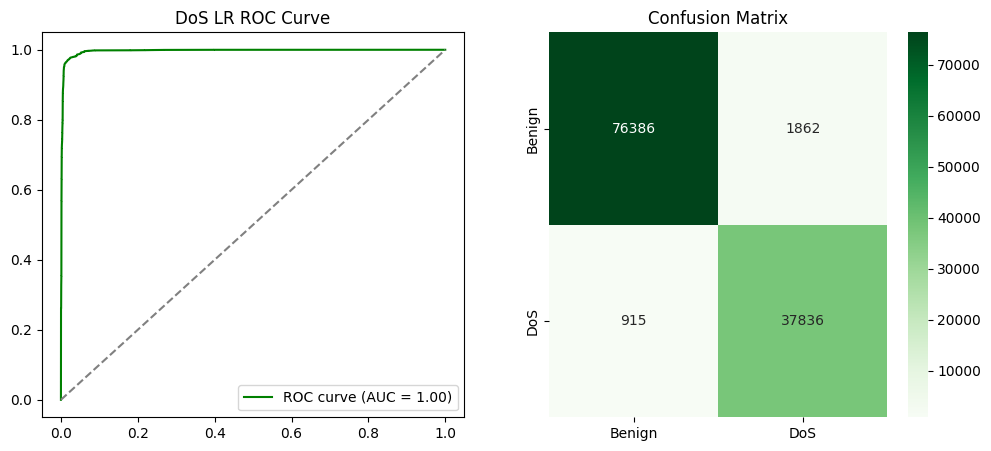

In [21]:
if __name__ == "__main__":
    # Load DoS Dataset
    data_path = "C:\\Datasets\\IDS_Dataset\\DoS-Wednesday-no-metadata.csv"
    X_train, X_test, y_train, y_test = load_and_preprocess(data_path)
    
    print(f"Original distribution: {np.bincount(y_train)}")

    smt = SMOTETomek(sampling_strategy=0.6, random_state=42)
    X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

    print(f"New balanced distribution: {np.bincount(y_train_res)}")
    # --- STEP 3: Initialize Logistic Regression for FL ---
    # Standardized parameters for round-based learning
    model = LogisticRegression(
        max_iter=2000,
        C=0.1, 
        warm_start=True, 
        solver='saga', 
        class_weight='balanced'
    )
    
    # Initial Local Training
    print("Training Logistic Regression on DoS data...")
    model.fit(X_train_res, y_train_res)
    
    # --- STEP 4: Evaluation ---
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # Classification Report
    print("\n--- CLASSIFICATION REPORT ---")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'DoS']))
    
    # ROC-AUC Calculation
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)
    
    # Plotting
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', color='green')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title('DoS LR ROC Curve')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Benign', 'DoS'], yticklabels=['Benign', 'DoS'])
    plt.title('Confusion Matrix')
    plt.show()

In [22]:
import joblib

# Save the model to a pkl file
joblib.dump(model, 'model_3.pkl') # Change name for each file
print("Model saved as pkl for Federated Aggregation.")

Model saved as pkl for Federated Aggregation.
